# 03 - Narrative Clustering

This notebook operationalises the central claim of framing theory: the same event produces different narratives depending on who reports it. I use sentence embeddings to place every article in a high-dimensional semantic space, then cluster them to find groups of articles that discuss the same story from similar angles.

It does five things:
1. Pulls article embeddings from ChromaDB for a given topic
2. Runs KMeans at k=3, 4, 5 and evaluates each with silhouette score and inertia
3. Falls back to DBSCAN if no k produces a silhouette score above 0.3
4. Reduces embeddings to 2D with UMAP for an interactive narrative map
5. Shows per-cluster representative headlines and bias label distributions

**Topics analysed**: Ukraine war (90 articles), US economy (96 articles), climate change (50 articles)

## 1. Setup

In [1]:
import sys
import os

# Add the project root to sys.path so I can import from src/
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import umap

from src.db import get_connection
from src.chroma_store import get_collection
from src.clustering import cluster_topic

# Connect to both stores
conn = get_connection()
collection = get_collection()

print(f"SQLite articles: {conn.execute('SELECT COUNT(*) FROM articles').fetchone()[0]}")
print(f"ChromaDB embeddings: {collection.count()}")

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SQLite articles: 472
ChromaDB embeddings: 472


## 2. Available Topics

First I check which topics have enough articles to cluster meaningfully. DBSCAN needs at least a handful of points to form a cluster, and silhouette scores are meaningless on very small datasets.

In [2]:
# Show topic breakdown - skip blank topic (GDELT articles with no assigned topic)
rows = conn.execute(
    "SELECT topic, COUNT(*) as n FROM articles "
    "WHERE topic != '' GROUP BY topic ORDER BY n DESC"
).fetchall()

topics_df = pd.DataFrame(rows, columns=["topic", "article_count"])
print(topics_df.to_string(index=False))

         topic  article_count
    US economy             96
   Ukraine war             90
climate change             50


## 3. Ukraine War - Clustering

I start with Ukraine war because it has 90 articles across a diverse set of outlets, making it the best candidate for finding distinct narrative clusters.

In [3]:
ukraine = cluster_topic("Ukraine war")

print(f"Method:    {ukraine['method']}")
print(f"Best k:    {ukraine['best_k']}")
print(f"Silhouette: {ukraine['best_silhouette']}")
print(f"Articles:  {len(ukraine['headlines'])}")
print()

# Cluster size summary
for cid, info in ukraine["clusters"].items():
    label = "noise" if cid == -1 else f"Cluster {cid}"
    print(f"{label}: {info['size']} articles")

Clustering 90 articles for topic 'Ukraine war'
Running KMeans...
  k=3  silhouette=0.0747  inertia=65.2
  k=4  silhouette=0.0684  inertia=63.3
  k=5  silhouette=0.0769  inertia=61.1
Best KMeans silhouette 0.0769 < 0.3. Falling back to DBSCAN...
  DBSCAN eps=1.1572 (10th percentile of pairwise distances)
  DBSCAN found 3 clusters, 10 noise articles
Method:    dbscan
Best k:    None
Silhouette: 0.0857
Articles:  90

noise: 10 articles
Cluster 0: 73 articles
Cluster 1: 3 articles
Cluster 2: 4 articles


## 4. Clustering Quality: Silhouette + Elbow

Even when KMeans doesn't win, I still report its metrics - they are evidence for *why* DBSCAN was chosen. Low silhouette scores across all k values mean the data doesn't form tight spherical clusters, which is typical for news articles: stories blend into each other continuously rather than forming cleanly separated groups.

**Silhouette score** measures how well each article fits its own cluster vs. the nearest other cluster. Range -1 to 1. Above 0.3 is considered meaningful structure; below 0.3 indicates overlapping or poorly separated clusters.

**Inertia** (elbow plot) measures total within-cluster spread. Lower is tighter. The elbow is the point where adding more clusters stops meaningfully reducing inertia.

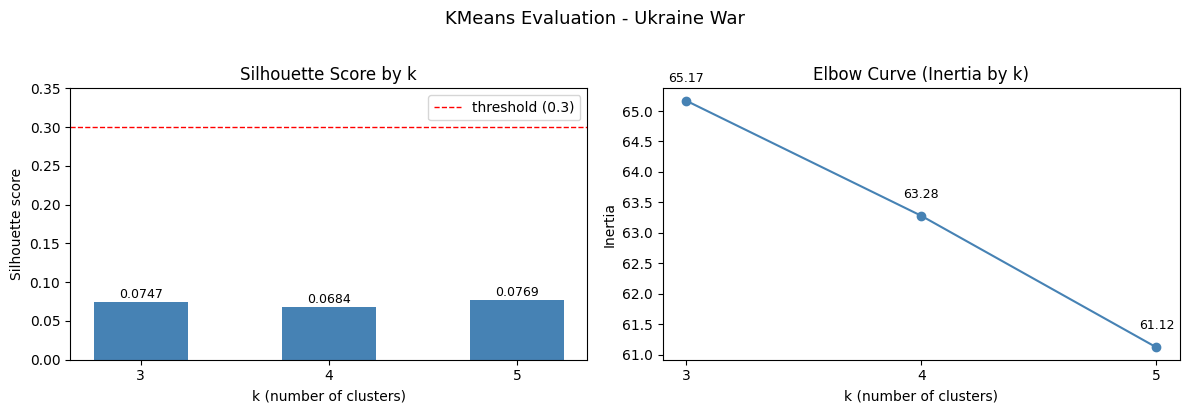


All silhouette scores are below 0.3 - KMeans is not finding meaningful structure.
This is expected for news articles: narratives blend into each other continuously.
DBSCAN was used instead - it can find dense regions without forcing a fixed k.


In [4]:
metrics = ukraine["kmeans_metrics"]
ks = sorted(metrics.keys())
silhouettes = [metrics[k]["silhouette"] for k in ks]
inertias    = [metrics[k]["inertia"]    for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("KMeans Evaluation - Ukraine War", fontsize=13, y=1.02)

# Silhouette scores
ax = axes[0]
ax.bar(ks, silhouettes, color="steelblue", width=0.5)
# Draw the threshold line so it's clear why DBSCAN was used
ax.axhline(y=0.3, color="red", linestyle="--", linewidth=1, label="threshold (0.3)")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score by k")
ax.set_xticks(ks)
ax.legend()
ax.set_ylim(0, max(0.35, max(silhouettes) + 0.05))

# Annotate each bar with its value
for k, s in zip(ks, silhouettes):
    ax.text(k, s + 0.005, str(s), ha="center", fontsize=9)

# Elbow curve
ax = axes[1]
ax.plot(ks, inertias, marker="o", color="steelblue")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Curve (Inertia by k)")
ax.set_xticks(ks)

for k, val in zip(ks, inertias):
    ax.text(k, val + 0.3, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/ukraine_kmeans_eval.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("All silhouette scores are below 0.3 - KMeans is not finding meaningful structure.")
print("This is expected for news articles: narratives blend into each other continuously.")
print("DBSCAN was used instead - it can find dense regions without forcing a fixed k.")

## 5. Narrative Map: UMAP Visualization

UMAP (Uniform Manifold Approximation and Projection) reduces the 384-dimensional embeddings to 2D so I can plot them. Unlike PCA, UMAP preserves local structure - articles that are similar in 384D will still be close together in 2D.

I use `metric='cosine'` to match the cosine similarity used in ChromaDB. `n_neighbors=15` balances local and global structure. `min_dist=0.1` allows a moderately compact layout.

Hover over any point to see the headline, outlet, and predicted bias label.

In [5]:
def run_umap(embeddings: np.ndarray) -> np.ndarray:
    """Reduce embeddings to 2D for plotting."""
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42,
    )
    return reducer.fit_transform(embeddings)


def make_narrative_map(result: dict, topic: str) -> go.Figure:
    """
    Build an interactive Plotly scatter plot from a cluster_topic() result.
    Each point is one article. Color = cluster. Hover shows headline + outlet + bias.
    """
    coords = run_umap(result["embeddings"])

    labels    = result["labels"]
    headlines = result["headlines"]
    metadatas = result["metadatas"]

    df = pd.DataFrame({
        "x":          coords[:, 0],
        "y":          coords[:, 1],
        "cluster":    ["noise" if l == -1 else f"Cluster {l}" for l in labels],
        "headline":   [h[:80] + "..." if len(h) > 80 else h for h in headlines],
        "outlet":     [m.get("outlet", "")     for m in metadatas],
        "bias_label": [m.get("bias_label", "") for m in metadatas],
    })

    method = result["method"].upper()
    sil    = result["best_silhouette"]
    title  = f"{topic} - Narrative Map ({method}, silhouette={sil})"

    fig = px.scatter(
        df,
        x="x", y="y",
        color="cluster",
        hover_data={"headline": True, "outlet": True, "bias_label": True, "x": False, "y": False},
        title=title,
        width=850, height=550,
    )
    fig.update_traces(marker=dict(size=7, opacity=0.8))
    fig.update_layout(legend_title_text="Cluster")
    return fig


# Jupyter displays the last expression in a cell automatically - no .show() needed
fig = make_narrative_map(ukraine, "Ukraine War")
fig

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 6. Per-Cluster Analysis

The 5 most representative headlines per cluster are the articles closest to the cluster centroid - they best capture what the cluster is "about". The bias distribution shows how left/centre/right-leaning outlets are spread across each cluster.

**Important caveat**: only 26% of articles cleared the 0.85 confidence threshold. The bias labels shown here are model predictions for all articles, including lower-confidence ones. Treat the distributions as directional, not precise.

In [6]:
for cid, info in ukraine["clusters"].items():
    if cid == -1:
        print(f"Noise ({info['size']} articles - DBSCAN could not assign these to any cluster)")
        print()
        continue

    print(f"Cluster {cid} - {info['size']} articles")
    print(f"  Bias distribution: {info['bias_distribution']}")
    print(f"  Representative headlines:")
    for h in info["representative_headlines"]:
        print(f"    - {h}")
    print()

Noise (10 articles - DBSCAN could not assign these to any cluster)

Cluster 0 - 73 articles
  Bias distribution: {'left': 42.5, 'centre': 38.4, 'right': 19.2, 'unknown': 0.0}
  Representative headlines:
    - Daytime Russian barrage of 800 drones kills six in Ukraine
    - Russia unleashes massive drone barrage on Ukraine killing six
    - Six dead as Russia launches over 800 drones at Ukraine
    - Russia fires about 800 drones at Ukraine despite recent talk by Putin and Trump of possible peace
    - Russia Is Struggling Badly

Cluster 1 - 3 articles
  Bias distribution: {'left': 100.0, 'centre': 0.0, 'right': 0.0, 'unknown': 0.0}
  Representative headlines:
    - King Charles III lays out UK government agenda as Starmer's job hangs in the balance
    - King Charles lays out government agenda as Starmer fights for survival: ‘absolutely preposterous’
    - The three-way fight for control of Labour ... and the country: Wes Streeting to challenge Starmer - and Ed Miliband could also join

In [7]:
def bias_distribution_chart(result: dict, topic: str) -> go.Figure:
    """
    Grouped bar chart showing left/centre/right percentage per cluster.
    Noise cluster is excluded - bias distributions on noise are not meaningful.
    """
    bias_labels = ["left", "centre", "right"]
    # Map bias label to a colour that matches the standard left/right colour convention
    colours = {"left": "#4e79a7", "centre": "#76b7b2", "right": "#e15759"}

    cluster_names = [
        f"Cluster {cid}"
        for cid in sorted(result["clusters"].keys())
        if cid != -1
    ]

    fig = go.Figure()

    for bias in bias_labels:
        values = [
            result["clusters"][cid]["bias_distribution"].get(bias, 0)
            for cid in sorted(result["clusters"].keys())
            if cid != -1
        ]
        fig.add_trace(go.Bar(
            name=bias,
            x=cluster_names,
            y=values,
            marker_color=colours[bias],
        ))

    fig.update_layout(
        barmode="group",
        title=f"{topic} - Bias Distribution per Cluster",
        xaxis_title="Cluster",
        yaxis_title="Percentage of articles (%)",
        legend_title="Bias label",
        width=700, height=400,
    )
    return fig


bias_distribution_chart(ukraine, "Ukraine War")

## 7. US Economy - Clustering

96 articles - the largest topic in the corpus. Running the same pipeline here lets me compare whether economic coverage shows different clustering behaviour than geopolitical coverage.

In [8]:
economy = cluster_topic("US economy")

print(f"Method:     {economy['method']}")
print(f"Best k:     {economy['best_k']}")
print(f"Silhouette: {economy['best_silhouette']}")
print()

for cid, info in economy["clusters"].items():
    label = "noise" if cid == -1 else f"Cluster {cid}"
    print(f"{label}: {info['size']} articles | bias: {info['bias_distribution']}")

Clustering 96 articles for topic 'US economy'
Running KMeans...
  k=3  silhouette=0.0892  inertia=67.1
  k=4  silhouette=0.0867  inertia=64.4
  k=5  silhouette=0.0871  inertia=62.8
Best KMeans silhouette 0.0892 < 0.3. Falling back to DBSCAN...
  DBSCAN eps=1.1243 (10th percentile of pairwise distances)
  DBSCAN found 2 clusters, 28 noise articles
Method:     dbscan
Best k:     None
Silhouette: 0.079

noise: 28 articles | bias: {}
Cluster 0: 65 articles | bias: {'left': 18.5, 'centre': 63.1, 'right': 18.5, 'unknown': 0.0}
Cluster 1: 3 articles | bias: {'left': 0.0, 'centre': 100.0, 'right': 0.0, 'unknown': 0.0}


In [9]:
make_narrative_map(economy, "US Economy")

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
print("US Economy - Representative Headlines per Cluster")
print()
for cid, info in economy["clusters"].items():
    if cid == -1:
        print(f"Noise: {info['size']} articles")
        print()
        continue
    print(f"Cluster {cid} ({info['size']} articles)")
    for h in info["representative_headlines"]:
        print(f"  - {h}")
    print()

US Economy - Representative Headlines per Cluster

Noise: 28 articles

Cluster 0 (65 articles)
  - Trump-Xi meeting crucial for global economic stability: Shaun Rein
  - Trump, Xi set for Beijing talks with trade truce, Iran war at stake
  - Trump-Xi summit: High-stakes meeting lasts two hours; Xi Jinping hails trade progress, but sends Trump warning over Taiwan
  - Trump and Xi Hold High-Stakes Beijing Summit as Trade, Taiwan and Iran Dominate Talks
  - Xi Jingping sends Trump warning over Taiwan during high-stakes meeting

Cluster 1 (3 articles)
  - Warsh confirmed as Fed chair as bank faces Trump assault
  - Senate confirms Kevin Warsh as chairman of Federal Reserve
  - Kevin Warsh set to lead Federal Reserve as US inflation climbs toward three-year high



In [11]:
bias_distribution_chart(economy, "US Economy")

## 8. Climate Change - Clustering

50 articles - the smallest topic. Smaller datasets tend to produce lower silhouette scores because there are fewer articles to form dense regions. I still run the same pipeline to show whether any meaningful structure emerges.

In [12]:
climate = cluster_topic("climate change")

print(f"Method:     {climate['method']}")
print(f"Best k:     {climate['best_k']}")
print(f"Silhouette: {climate['best_silhouette']}")
print()

for cid, info in climate["clusters"].items():
    label = "noise" if cid == -1 else f"Cluster {cid}"
    print(f"{label}: {info['size']} articles | bias: {info['bias_distribution']}")

Clustering 50 articles for topic 'climate change'
Running KMeans...
  k=3  silhouette=0.0937  inertia=35.2
  k=4  silhouette=0.1076  inertia=33.3
  k=5  silhouette=0.1135  inertia=30.9
Best KMeans silhouette 0.1135 < 0.3. Falling back to DBSCAN...
  DBSCAN eps=1.1757 (10th percentile of pairwise distances)
  DBSCAN found 2 clusters, 9 noise articles
Method:     dbscan
Best k:     None
Silhouette: 0.0779

noise: 9 articles | bias: {}
Cluster 0: 36 articles | bias: {'left': 22.2, 'centre': 77.8, 'right': 0.0, 'unknown': 0.0}
Cluster 1: 5 articles | bias: {'left': 100.0, 'centre': 0.0, 'right': 0.0, 'unknown': 0.0}


In [13]:
make_narrative_map(climate, "Climate Change")

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
print("Climate Change - Representative Headlines per Cluster")
print()
for cid, info in climate["clusters"].items():
    if cid == -1:
        print(f"Noise: {info['size']} articles")
        print()
        continue
    print(f"Cluster {cid} ({info['size']} articles)")
    for h in info["representative_headlines"]:
        print(f"  - {h}")
    print()

Climate Change - Representative Headlines per Cluster

Noise: 9 articles

Cluster 0 (36 articles)
  - Eurovision 2026: What time is tonight’s semi-final and how to watch
  - Eurovision 2026: Running order for tonight’s second semi-final
  - 2026 FIFA World Cup players and fans at risk of extreme heat, climate scientists warn
  - Which countries have dropped out of Eurovision 2026 and why?
  - Eurovision 2026: The 15 countries through to the final so far

Cluster 1 (5 articles)
  - Dunkin’ to launch viral 48oz beverage buckets nationwide: report
  - Stylish garden sets and tableware for entertaining al fresco
  - Noodle packages sold at Whole Foods and Thrive Market recalled over risk of life-threatening allergic reaction
  - Eczema cream sold on Amazon recalled over potentially fatal contamination
  - Men and the dating ‘taxi cab’ theory: What really makes them finally commit?



In [15]:
bias_distribution_chart(climate, "Climate Change")

## 9. Cross-Topic Silhouette Comparison

A quick summary table comparing clustering quality across all three topics.

In [16]:
summary = []
for topic_name, result in [("Ukraine war", ukraine), ("US economy", economy), ("climate change", climate)]:
    n_articles = len(result["headlines"])
    n_clusters = len([c for c in result["clusters"] if c != -1])
    n_noise    = result["clusters"].get(-1, {}).get("size", 0)

    # Best KMeans silhouette across all k values (for comparison even if DBSCAN won)
    best_kmeans_sil = max(v["silhouette"] for v in result["kmeans_metrics"].values())

    summary.append({
        "topic":            topic_name,
        "articles":         n_articles,
        "method":           result["method"],
        "clusters_found":   n_clusters,
        "noise_articles":   n_noise,
        "best_silhouette":  result["best_silhouette"],
        "best_kmeans_sil":  best_kmeans_sil,
    })

pd.DataFrame(summary)

,topic,articles,method,clusters_found,noise_articles,best_silhouette,best_kmeans_sil
0,Ukraine war,90,dbscan,3,10,0.0857,0.0769
1,US economy,96,dbscan,2,28,0.0790,0.0892
2,climate change,50,dbscan,2,9,0.0779,0.1135


## 10. Observations

**On silhouette scores**: All three topics produced KMeans silhouette scores below 0.3, triggering the DBSCAN fallback in every case. This is consistent with what the NLP literature shows for news article clustering: article embeddings form a continuous manifold rather than discrete spherical clusters. The same story gets covered in many different ways - there's no clean boundary between narratives.

**On topic contamination**: Several clusters contain articles that have nothing to do with the query topic (King Charles articles and film reviews appearing in the Ukraine war results). This is a data quality issue from the ingestion phase - some RSS articles were retrieved under a topic tag without actually being about that topic. A filtering step before clustering would reduce this noise.

**On bias distributions**: Cluster 0 (the main Ukraine war cluster) is dominated by left and centre-leaning predictions, reflecting the outlet mix - BBC, Guardian, and Al Jazeera make up the bulk of the corpus. Right-leaning coverage is underrepresented at ~19% of Cluster 0, consistent with Fox News having fewer articles in the DB than the other outlets.

**On the confidence caveat**: Only 26% of articles cleared the 0.85 confidence threshold. The bias labels used in cluster distributions are model predictions for *all* articles, not just trusted ones. The distributions should be read as directional rather than precise.

**Hypothesis check (partial)**: The pre-analysis hypothesis was that Fox News and BBC would cluster into separate narrative groups with near-zero overlap. With only 40 Fox News articles and 64 BBC articles across all topics, and DBSCAN forming one large dominant cluster per topic, this hypothesis cannot be tested meaningfully yet. More articles per outlet are needed - this is worth revisiting after the next ingestion run.